# Pokémon Team Recommender
Loads the trained EfficientNet-B0 checkpoint and recommends the best 6th team member.

**No retraining needed** — runs in seconds.

| Section | Description |
|---------|-------------|
| 0 | Setup & model load |
| 1 | Pokémon data (base stats + type weaknesses) |
| 2 | Recommendation functions |
| 3 | Random team — pick 5 random images, classify, recommend |
| 4 | Compare multiple teams at once |
| 5 | Experiment with recommendation weights |

---
## 0. Setup

In [10]:
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_b0

warnings.filterwarnings('ignore')

DATA_DIR    = Path('PokemonData')
MODEL_PATH  = Path('best_model_v2.pth')  # change to 'best_model.pth' to use v1
STATS_CACHE = Path('pokemon_stats.json')
IMG_SIZE    = 224
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def list_images(folder):
    return [p for p in Path(folder).iterdir() if p.suffix.lower() in IMG_EXTS]

print(f'Device: {DEVICE}')

Device: cuda


In [11]:
class_names  = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES  = len(class_names)
idx_to_class = {i: name for i, name in enumerate(class_names)}

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE).eval()

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f'Model loaded  — {NUM_CLASSES} classes')

Model loaded  — 150 classes


---
## 1. Pokémon Data

### 1a. Base stats from PokéAPI
Fetches HP / Attack / Defense / Sp.Atk / Sp.Def / Speed for all 150 Pokémon and caches them to `pokemon_stats.json`.  
On subsequent runs the cache is loaded instantly (no internet needed).

In [12]:
# Dataset names → PokéAPI slugs (only non-trivial mappings needed)
NAME_TO_API = {
    'Alolan Sandslash': 'sandslash-alola',
    'MrMime':           'mr-mime',
    'Farfetchd':        'farfetchd',
}

def fetch_stats(name):
    slug = NAME_TO_API.get(name, name.lower().replace(' ', '-'))
    r = requests.get(f'https://pokeapi.co/api/v2/pokemon/{slug}', timeout=10)
    r.raise_for_status()
    return {s['stat']['name']: s['base_stat'] for s in r.json()['stats']}

if STATS_CACHE.exists():
    with open(STATS_CACHE) as f:
        POKEMON_STATS = json.load(f)
    print(f'Loaded stats from cache  ({len(POKEMON_STATS)} Pokémon)')
else:
    print('Fetching stats from PokéAPI — this runs once, then cached...')
    POKEMON_STATS = {}
    for i, name in enumerate(class_names, 1):
        try:
            POKEMON_STATS[name] = fetch_stats(name)
            print(f'  [{i:3d}/{NUM_CLASSES}] {name}')
        except Exception as e:
            print(f'  [{i:3d}/{NUM_CLASSES}] WARNING — could not fetch {name}: {e}')
    with open(STATS_CACHE, 'w') as f:
        json.dump(POKEMON_STATS, f, indent=2)
    print(f'\nDone. Cached to {STATS_CACHE}')

Loaded stats from cache  (150 Pokémon)


### 1b. Type chart & Pokémon types

In [13]:
# Attacking types that deal 2x damage to each defending type
TYPE_WEAKNESSES = {
    'Normal':   ['Fighting'],
    'Fire':     ['Water', 'Ground', 'Rock'],
    'Water':    ['Electric', 'Grass'],
    'Electric': ['Ground'],
    'Grass':    ['Fire', 'Ice', 'Poison', 'Flying', 'Bug'],
    'Ice':      ['Fire', 'Fighting', 'Rock', 'Steel'],
    'Fighting': ['Flying', 'Psychic', 'Fairy'],
    'Poison':   ['Ground', 'Psychic'],
    'Ground':   ['Water', 'Grass', 'Ice'],
    'Flying':   ['Electric', 'Ice', 'Rock'],
    'Psychic':  ['Bug', 'Ghost', 'Dark'],
    'Bug':      ['Fire', 'Flying', 'Rock'],
    'Rock':     ['Water', 'Grass', 'Fighting', 'Ground', 'Steel'],
    'Ghost':    ['Ghost', 'Dark'],
    'Dragon':   ['Ice', 'Dragon', 'Fairy'],
    'Steel':    ['Fire', 'Fighting', 'Ground'],
    'Fairy':    ['Poison', 'Steel'],
    'Dark':     ['Fighting', 'Bug', 'Fairy'],
}

# Types that grant full immunity
TYPE_IMMUNITIES = {
    'Normal':   ['Ghost'],
    'Ghost':    ['Normal', 'Fighting'],
    'Ground':   ['Electric'],
    'Flying':   ['Ground'],
    'Dark':     ['Psychic'],
    'Steel':    ['Poison'],
    'Fairy':    ['Dragon'],
}

POKEMON_TYPES = {
    'Abra': ['Psychic'],
    'Aerodactyl': ['Rock', 'Flying'],
    'Alakazam': ['Psychic'],
    'Alolan Sandslash': ['Ice', 'Steel'],
    'Arbok': ['Poison'],
    'Arcanine': ['Fire'],
    'Articuno': ['Ice', 'Flying'],
    'Beedrill': ['Bug', 'Poison'],
    'Bellsprout': ['Grass', 'Poison'],
    'Blastoise': ['Water'],
    'Bulbasaur': ['Grass', 'Poison'],
    'Butterfree': ['Bug', 'Flying'],
    'Caterpie': ['Bug'],
    'Chansey': ['Normal'],
    'Charizard': ['Fire', 'Flying'],
    'Charmander': ['Fire'],
    'Charmeleon': ['Fire'],
    'Clefable': ['Fairy'],
    'Clefairy': ['Fairy'],
    'Cloyster': ['Water', 'Ice'],
    'Cubone': ['Ground'],
    'Dewgong': ['Water', 'Ice'],
    'Diglett': ['Ground'],
    'Ditto': ['Normal'],
    'Dodrio': ['Normal', 'Flying'],
    'Doduo': ['Normal', 'Flying'],
    'Dragonair': ['Dragon'],
    'Dragonite': ['Dragon', 'Flying'],
    'Dratini': ['Dragon'],
    'Drowzee': ['Psychic'],
    'Dugtrio': ['Ground'],
    'Eevee': ['Normal'],
    'Ekans': ['Poison'],
    'Electabuzz': ['Electric'],
    'Electrode': ['Electric'],
    'Exeggcute': ['Grass', 'Psychic'],
    'Exeggutor': ['Grass', 'Psychic'],
    'Farfetchd': ['Normal', 'Flying'],
    'Fearow': ['Normal', 'Flying'],
    'Flareon': ['Fire'],
    'Gastly': ['Ghost', 'Poison'],
    'Gengar': ['Ghost', 'Poison'],
    'Geodude': ['Rock', 'Ground'],
    'Gloom': ['Grass', 'Poison'],
    'Golbat': ['Poison', 'Flying'],
    'Goldeen': ['Water'],
    'Golduck': ['Water'],
    'Golem': ['Rock', 'Ground'],
    'Graveler': ['Rock', 'Ground'],
    'Grimer': ['Poison'],
    'Growlithe': ['Fire'],
    'Gyarados': ['Water', 'Flying'],
    'Haunter': ['Ghost', 'Poison'],
    'Hitmonchan': ['Fighting'],
    'Hitmonlee': ['Fighting'],
    'Horsea': ['Water'],
    'Hypno': ['Psychic'],
    'Ivysaur': ['Grass', 'Poison'],
    'Jigglypuff': ['Normal', 'Fairy'],
    'Jolteon': ['Electric'],
    'Jynx': ['Ice', 'Psychic'],
    'Kabuto': ['Rock', 'Water'],
    'Kabutops': ['Rock', 'Water'],
    'Kadabra': ['Psychic'],
    'Kakuna': ['Bug', 'Poison'],
    'Kangaskhan': ['Normal'],
    'Kingler': ['Water'],
    'Koffing': ['Poison'],
    'Krabby': ['Water'],
    'Lapras': ['Water', 'Ice'],
    'Lickitung': ['Normal'],
    'Machamp': ['Fighting'],
    'Machoke': ['Fighting'],
    'Machop': ['Fighting'],
    'Magikarp': ['Water'],
    'Magmar': ['Fire'],
    'Magnemite': ['Electric', 'Steel'],
    'Magneton': ['Electric', 'Steel'],
    'Mankey': ['Fighting'],
    'Marowak': ['Ground'],
    'Meowth': ['Normal'],
    'Metapod': ['Bug'],
    'Mew': ['Psychic'],
    'Mewtwo': ['Psychic'],
    'Moltres': ['Fire', 'Flying'],
    'MrMime': ['Psychic', 'Fairy'],
    'Muk': ['Poison'],
    'Nidoking': ['Poison', 'Ground'],
    'Nidoqueen': ['Poison', 'Ground'],
    'Nidorina': ['Poison'],
    'Nidorino': ['Poison'],
    'Ninetales': ['Fire'],
    'Oddish': ['Grass', 'Poison'],
    'Omanyte': ['Rock', 'Water'],
    'Omastar': ['Rock', 'Water'],
    'Onix': ['Rock', 'Ground'],
    'Paras': ['Bug', 'Grass'],
    'Parasect': ['Bug', 'Grass'],
    'Persian': ['Normal'],
    'Pidgeot': ['Normal', 'Flying'],
    'Pidgeotto': ['Normal', 'Flying'],
    'Pidgey': ['Normal', 'Flying'],
    'Pikachu': ['Electric'],
    'Pinsir': ['Bug'],
    'Poliwag': ['Water'],
    'Poliwhirl': ['Water'],
    'Poliwrath': ['Water', 'Fighting'],
    'Ponyta': ['Fire'],
    'Porygon': ['Normal'],
    'Primeape': ['Fighting'],
    'Psyduck': ['Water'],
    'Raichu': ['Electric'],
    'Rapidash': ['Fire'],
    'Raticate': ['Normal'],
    'Rattata': ['Normal'],
    'Rhydon': ['Ground', 'Rock'],
    'Rhyhorn': ['Ground', 'Rock'],
    'Sandshrew': ['Ground'],
    'Sandslash': ['Ground'],
    'Scyther': ['Bug', 'Flying'],
    'Seadra': ['Water'],
    'Seaking': ['Water'],
    'Seel': ['Water'],
    'Shellder': ['Water'],
    'Slowbro': ['Water', 'Psychic'],
    'Slowpoke': ['Water', 'Psychic'],
    'Snorlax': ['Normal'],
    'Spearow': ['Normal', 'Flying'],
    'Squirtle': ['Water'],
    'Starmie': ['Water', 'Psychic'],
    'Staryu': ['Water'],
    'Tangela': ['Grass'],
    'Tauros': ['Normal'],
    'Tentacool': ['Water', 'Poison'],
    'Tentacruel': ['Water', 'Poison'],
    'Vaporeon': ['Water'],
    'Venomoth': ['Bug', 'Poison'],
    'Venonat': ['Bug', 'Poison'],
    'Venusaur': ['Grass', 'Poison'],
    'Victreebel': ['Grass', 'Poison'],
    'Vileplume': ['Grass', 'Poison'],
    'Voltorb': ['Electric'],
    'Vulpix': ['Fire'],
    'Wartortle': ['Water'],
    'Weedle': ['Bug', 'Poison'],
    'Weepinbell': ['Grass', 'Poison'],
    'Weezing': ['Poison'],
    'Wigglytuff': ['Normal', 'Fairy'],
    'Zapdos': ['Electric', 'Flying'],
    'Zubat': ['Poison', 'Flying'],
}

In [14]:
# Evolution chains present in the dataset
# When recommending, only the highest-BST member of each chain is shown
EVOLUTION_CHAINS = [
    ['Bulbasaur', 'Ivysaur', 'Venusaur'],
    ['Charmander', 'Charmeleon', 'Charizard'],
    ['Squirtle', 'Wartortle', 'Blastoise'],
    ['Caterpie', 'Metapod', 'Butterfree'],
    ['Weedle', 'Kakuna', 'Beedrill'],
    ['Pidgey', 'Pidgeotto', 'Pidgeot'],
    ['Rattata', 'Raticate'],
    ['Spearow', 'Fearow'],
    ['Ekans', 'Arbok'],
    ['Pikachu', 'Raichu'],
    ['Sandshrew', 'Sandslash'],
    ['Nidorina', 'Nidoqueen'],
    ['Nidorino', 'Nidoking'],
    ['Clefairy', 'Clefable'],
    ['Jigglypuff', 'Wigglytuff'],
    ['Zubat', 'Golbat'],
    ['Oddish', 'Gloom', 'Vileplume'],
    ['Paras', 'Parasect'],
    ['Venonat', 'Venomoth'],
    ['Diglett', 'Dugtrio'],
    ['Meowth', 'Persian'],
    ['Psyduck', 'Golduck'],
    ['Mankey', 'Primeape'],
    ['Growlithe', 'Arcanine'],
    ['Poliwag', 'Poliwhirl', 'Poliwrath'],
    ['Abra', 'Kadabra', 'Alakazam'],
    ['Machop', 'Machoke', 'Machamp'],
    ['Bellsprout', 'Weepinbell', 'Victreebel'],
    ['Tentacool', 'Tentacruel'],
    ['Geodude', 'Graveler', 'Golem'],
    ['Ponyta', 'Rapidash'],
    ['Slowpoke', 'Slowbro'],
    ['Magnemite', 'Magneton'],
    ['Doduo', 'Dodrio'],
    ['Seel', 'Dewgong'],
    ['Grimer', 'Muk'],
    ['Shellder', 'Cloyster'],
    ['Gastly', 'Haunter', 'Gengar'],
    ['Drowzee', 'Hypno'],
    ['Krabby', 'Kingler'],
    ['Voltorb', 'Electrode'],
    ['Exeggcute', 'Exeggutor'],
    ['Cubone', 'Marowak'],
    ['Koffing', 'Weezing'],
    ['Rhyhorn', 'Rhydon'],
    ['Horsea', 'Seadra'],
    ['Goldeen', 'Seaking'],
    ['Staryu', 'Starmie'],
    ['Magikarp', 'Gyarados'],
    ['Eevee', 'Vaporeon', 'Jolteon', 'Flareon'],  # different types — kept by best score on BST tie
    ['Omanyte', 'Omastar'],
    ['Kabuto', 'Kabutops'],
    ['Dratini', 'Dragonair', 'Dragonite'],
]

CHAIN_MAP = {
    pokemon: chain_id
    for chain_id, chain in enumerate(EVOLUTION_CHAINS)
    for pokemon in chain
}

print(f'Evolution chains : {len(EVOLUTION_CHAINS)}')

Evolution chains : 53


---
## 2. Functions

### Composite recommendation score

```
score = w_type × new_types_added
      + w_weak × weakness_coverage
      + w_role × fills_missing_role
```

- **new_types_added**: types the candidate brings that the team doesn't already have
- **weakness_coverage**: tiered score for each shared team weakness the candidate handles:
  - Immune (0×) → 2 pts
  - Resists (0.5×) → 1.5 pts
  - Neutral (avoids) → 1 pt
- **fills_missing_role**: 1 if the candidate's role (sweeper / tank / balanced) is underrepresented

Roles are derived from base stats:
- **sweeper** — Atk + Sp.Atk + Speed dominates
- **tank** — HP + Def + Sp.Def dominates
- **balanced** — neither extreme

In [15]:
# Attacking types that deal 0.5× damage to each defending type
TYPE_RESISTANCES = {
    'Normal':   [],
    'Fire':     ['Fire', 'Grass', 'Ice', 'Bug', 'Steel', 'Fairy'],
    'Water':    ['Fire', 'Water', 'Ice', 'Steel'],
    'Electric': ['Electric', 'Flying', 'Steel'],
    'Grass':    ['Water', 'Grass', 'Electric', 'Ground'],
    'Ice':      ['Ice'],
    'Fighting': ['Bug', 'Rock', 'Dark'],
    'Poison':   ['Grass', 'Fighting', 'Poison', 'Bug', 'Fairy'],
    'Ground':   ['Poison', 'Rock'],
    'Flying':   ['Grass', 'Fighting', 'Bug'],
    'Psychic':  ['Fighting', 'Psychic'],
    'Bug':      ['Grass', 'Fighting', 'Ground'],
    'Rock':     ['Normal', 'Fire', 'Poison', 'Flying'],
    'Ghost':    ['Poison', 'Bug'],
    'Dragon':   ['Fire', 'Water', 'Electric', 'Grass'],
    'Steel':    ['Normal', 'Grass', 'Ice', 'Flying', 'Psychic', 'Bug', 'Rock', 'Dragon', 'Steel', 'Fairy'],
    'Fairy':    ['Fighting', 'Bug', 'Dark'],
    'Dark':     ['Ghost', 'Dark'],
}

LEGENDARIES = {'Articuno', 'Zapdos', 'Moltres', 'Mewtwo', 'Mew'}


def get_weaknesses(pokemon_name):
    """Return the set of attacking types this Pokemon is weak to (2×)."""
    types = POKEMON_TYPES.get(pokemon_name, [])
    weak = set()
    for t in types:
        weak.update(TYPE_WEAKNESSES.get(t, []))
    for t in types:
        for immune in TYPE_IMMUNITIES.get(t, []):
            weak.discard(immune)
    return weak


def get_immunities(pokemon_name):
    """Return the set of attacking types this Pokemon is immune to (0×)."""
    types = POKEMON_TYPES.get(pokemon_name, [])
    immunes = set()
    for t in types:
        immunes.update(TYPE_IMMUNITIES.get(t, []))
    return immunes


def get_resistances(pokemon_name):
    """Return the set of attacking types this Pokemon resists (0.5×), excluding immunities."""
    types = POKEMON_TYPES.get(pokemon_name, [])
    resists = set()
    for t in types:
        resists.update(TYPE_RESISTANCES.get(t, []))
    resists -= get_weaknesses(pokemon_name)  # dual-type: weakness cancels resistance
    resists -= get_immunities(pokemon_name)  # immunities scored separately
    return resists


def get_role(pokemon_name):
    """Classify as sweeper / tank / balanced based on base stats."""
    s = POKEMON_STATS.get(pokemon_name, {})
    if not s:
        return 'balanced'
    offensive = s.get('attack', 0) + s.get('special-attack', 0) + s.get('speed', 0)
    defensive = s.get('hp', 0)     + s.get('defense', 0)        + s.get('special-defense', 0)
    if offensive > defensive + 40:
        return 'sweeper'
    if defensive > offensive + 40:
        return 'tank'
    return 'balanced'


def bst(pokemon_name):
    """Base stat total."""
    return sum(POKEMON_STATS.get(pokemon_name, {}).values())


def recommend_sixth(team_of_5, top_n=5, w_type=1.0, w_weak=1.5, w_role=1.0, min_bst=500):
    """
    Composite recommendation: type coverage + weakness mitigation + role balance.
    - min_bst     : filters out pre-evolutions (default 500)
    - Chain filter: only the best candidate per evolution line is shown
    - Legendaries : Articuno, Zapdos, Moltres, Mewtwo, Mew are excluded
    - w_type / w_weak / w_role : tune the importance of each criterion

    Weakness coverage is tiered per shared weakness:
      immune (0×)  → 2.0 pts × w_weak
      resists (0.5×) → 1.5 pts × w_weak
      neutral (avoids) → 1.0 pt × w_weak
    """
    assert len(team_of_5) == 5, 'Team must have exactly 5 Pokemon.'

    team_types = set()
    for p in team_of_5:
        team_types.update(POKEMON_TYPES.get(p, []))

    weak_counts = {}
    for p in team_of_5:
        for w in get_weaknesses(p):
            weak_counts[w] = weak_counts.get(w, 0) + 1
    shared_weak = {t for t, c in weak_counts.items() if c >= 2}

    team_roles    = [get_role(p) for p in team_of_5]
    missing_roles = {'sweeper', 'tank', 'balanced'} - set(team_roles)

    # Score all valid candidates
    scores = {}
    for pokemon in POKEMON_TYPES:
        if pokemon in team_of_5:
            continue
        if pokemon in LEGENDARIES:
            continue
        if bst(pokemon) < min_bst:
            continue
        cand_weaks   = get_weaknesses(pokemon)
        cand_immunes = get_immunities(pokemon)
        cand_resists = get_resistances(pokemon)

        type_score = len(set(POKEMON_TYPES[pokemon]) - team_types)

        weak_score = 0.0
        for w in shared_weak:
            if w in cand_immunes:
                weak_score += 2.0   # immune: complete coverage
            elif w in cand_resists:
                weak_score += 1.5   # resists: strong coverage
            elif w not in cand_weaks:
                weak_score += 1.0   # neutral: avoids the liability

        role_score = 1 if get_role(pokemon) in missing_roles else 0
        scores[pokemon] = w_type * type_score + w_weak * weak_score + w_role * role_score

    # Keep only the best candidate per evolution chain
    # Primary: highest BST  |  Tiebreak: highest score (handles Eevee-lutions)
    chain_best = {}
    for pokemon, score in scores.items():
        chain_id = CHAIN_MAP.get(pokemon, pokemon)
        current  = chain_best.get(chain_id)
        if (current is None
                or bst(pokemon) > bst(current[0])
                or (bst(pokemon) == bst(current[0]) and score > current[1])):
            chain_best[chain_id] = (pokemon, score)
    scores = {p: s for p, s in chain_best.values()}

    ranked = sorted(scores.items(), key=lambda x: (-x[1], x[0]))

    print(f'Team          : {team_of_5}')
    print(f'Types covered : {sorted(team_types)}')
    print(f'Shared weaknesses (≥2 members): {sorted(shared_weak) or "none"}')
    print(f'Team roles    : { {p: get_role(p) for p in team_of_5} }')
    print(f'Missing roles : {sorted(missing_roles) or "none"}')
    print(f'Candidates    : {len(scores)} (BST ≥ {min_bst}, chain dedup, no legendaries)')
    print(f'\nTop {top_n} recommendations (w_type={w_type}, w_weak={w_weak}, w_role={w_role}):')
    for rank, (pokemon, score) in enumerate(ranked[:top_n], 1):
        new_types    = sorted(set(POKEMON_TYPES[pokemon]) - team_types)
        cand_weaks   = get_weaknesses(pokemon)
        cand_immunes = get_immunities(pokemon)
        cand_resists = get_resistances(pokemon)
        sw_immune  = sorted(shared_weak & cand_immunes)
        sw_resists = sorted(shared_weak & cand_resists)
        sw_avoids  = sorted(shared_weak - cand_weaks - cand_immunes - cand_resists)
        print(
            f'  {rank}. {pokemon:22s}  score={score:.1f} | '
            f'new types={new_types} | '
            f'immune={sw_immune} resists={sw_resists} avoids={sw_avoids} | '
            f'role={get_role(pokemon)} | BST={bst(pokemon)}'
        )

    return [p for p, _ in ranked[:top_n]]


def classify_image(img_path):
    """Run inference on one image and return the predicted Pokemon name."""
    img    = Image.open(img_path).convert('RGB')
    tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs        = torch.softmax(model(tensor), dim=1)[0]
        top_p, top_i = probs.topk(5)
    print(f'Image: {Path(img_path).name}')
    for p, i in zip(top_p, top_i):
        print(f'  {idx_to_class[i.item()]:22s} {p.item()*100:.1f}%')
    return idx_to_class[top_i[0].item()]


def visualize_team(team_names, rec_name, image_paths):
    """Show the 5-member team and the recommended 6th side by side."""
    fig, axes = plt.subplots(1, 6, figsize=(18, 4))
    for ax, name, path in zip(axes[:5], team_names, image_paths):
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(f'{name}\n{get_role(name)} | BST {bst(name)}', fontsize=8)
        ax.axis('off')
    rec_img = random.choice(list_images(DATA_DIR / rec_name))
    axes[5].imshow(Image.open(rec_img).convert('RGB'))
    axes[5].set_title(
        f'Recommended:\n{rec_name}\n{get_role(rec_name)} | BST {bst(rec_name)}',
        fontsize=8, color='green', fontweight='bold'
    )
    axes[5].axis('off')
    for spine in axes[5].spines.values():
        spine.set_edgecolor('green')
        spine.set_linewidth(3)
    plt.suptitle('Your Team of 5  →  Recommended 6th Member', fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 3. Random Team
Picks 5 random images from the dataset, classifies them, and recommends the 6th member.  
Re-run this cell as many times as you like.

=== Classifying 5 Pokemon images ===
Image: c45078d0ca914e61b34eb979ee243fab.jpg
  Dewgong                99.3%
  Seel                   0.2%
  Aerodactyl             0.1%
  Pidgeot                0.1%
  Tauros                 0.0%

Image: fb95b5635b8145d98ad718ceeb7b6691.jpg
  Poliwag                99.7%
  Horsea                 0.2%
  Tentacool              0.0%
  Voltorb                0.0%
  Magnemite              0.0%

Image: bb60c4727f0f4671b14a6af1250d6f81.jpg
  Hypno                  98.5%
  Abra                   0.8%
  Dragonite              0.2%
  Wartortle              0.1%
  Persian                0.1%

Image: 4e212eea2db64b1f92fe2347b9619eb1.jpg
  Lickitung              99.7%
  Dugtrio                0.1%
  Vileplume              0.0%
  Slowbro                0.0%
  Slowpoke               0.0%

Image: 16ec9494900e4fb4bccb4a9ae8408aa8.jpg
  Charizard              100.0%
  Dragonite              0.0%
  Charmander             0.0%
  Kingler                0.0%
  Lapras     

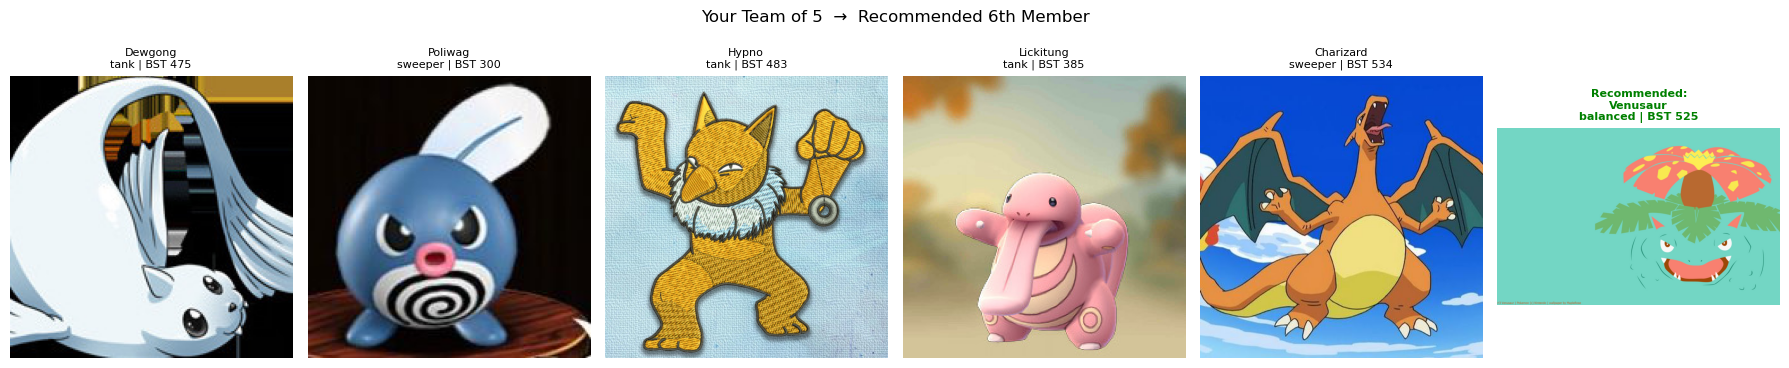

In [16]:
demo_pokemon = random.sample(class_names, 5)
demo_paths   = [random.choice(list_images(DATA_DIR / p)) for p in demo_pokemon]

print('=== Classifying 5 Pokemon images ===')
predicted_team = []
for path in demo_paths:
    name = classify_image(path)
    predicted_team.append(name)
    print()

print('\n=== Recommendation ===')
top_picks = recommend_sixth(predicted_team)
visualize_team(predicted_team, top_picks[0], demo_paths)

---
## 4. Compare Multiple Teams
Edit `TEAMS` to compare specific team compositions side by side.

------------------------------------------------------------
Team 1
Team          : ['Charizard', 'Blastoise', 'Venusaur', 'Pikachu', 'Snorlax']
Types covered : ['Electric', 'Fire', 'Flying', 'Grass', 'Normal', 'Poison', 'Water']
Shared weaknesses (≥2 members): ['Electric', 'Ground', 'Ice']
Team roles    : {'Charizard': 'sweeper', 'Blastoise': 'balanced', 'Venusaur': 'balanced', 'Pikachu': 'sweeper', 'Snorlax': 'tank'}
Missing roles : none
Candidates    : 22 (BST ≥ 500, chain dedup, no legendaries)

Top 3 recommendations (w_type=1.0, w_weak=1.5, w_role=1.0):
  1. Pinsir                  score=6.2 | new types=['Bug'] | immune=[] resists=['Ground'] avoids=['Electric', 'Ice'] | role=balanced | BST=500
  2. Alakazam                score=5.5 | new types=['Psychic'] | immune=[] resists=[] avoids=['Electric', 'Ground', 'Ice'] | role=sweeper | BST=500
  3. Exeggutor               score=5.5 | new types=['Psychic'] | immune=[] resists=['Electric', 'Ground'] avoids=[] | role=balanced | BST=530


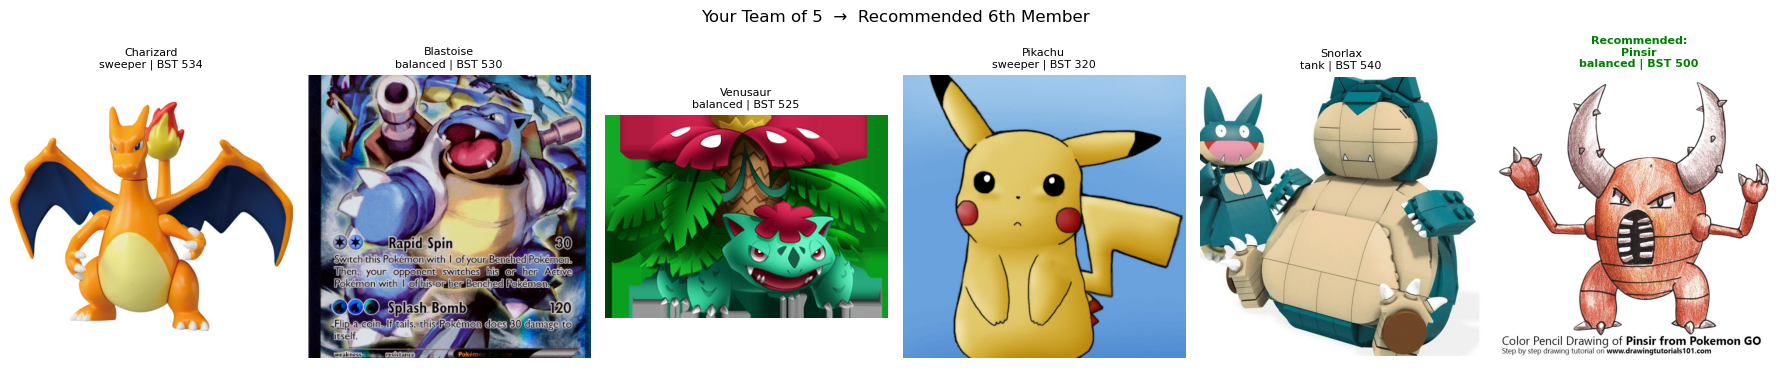


------------------------------------------------------------
Team 2
Team          : ['Mewtwo', 'Dragonite', 'Gengar', 'Machamp', 'Lapras']
Types covered : ['Dragon', 'Fighting', 'Flying', 'Ghost', 'Ice', 'Poison', 'Psychic', 'Water']
Shared weaknesses (≥2 members): ['Dark', 'Electric', 'Fairy', 'Ghost', 'Psychic', 'Rock']
Team roles    : {'Mewtwo': 'sweeper', 'Dragonite': 'balanced', 'Gengar': 'sweeper', 'Machamp': 'balanced', 'Lapras': 'tank'}
Missing roles : none
Candidates    : 22 (BST ≥ 500, chain dedup, no legendaries)

Top 3 recommendations (w_type=1.0, w_weak=1.5, w_role=1.0):
  1. Nidoking                score=11.5 | new types=['Ground'] | immune=['Electric'] resists=['Fairy', 'Rock'] avoids=['Dark', 'Ghost'] | role=balanced | BST=505
  2. Nidoqueen               score=11.5 | new types=['Ground'] | immune=['Electric'] resists=['Fairy', 'Rock'] avoids=['Dark', 'Ghost'] | role=balanced | BST=505
  3. Snorlax                 score=11.5 | new types=['Normal'] | immune=['Ghost'] re

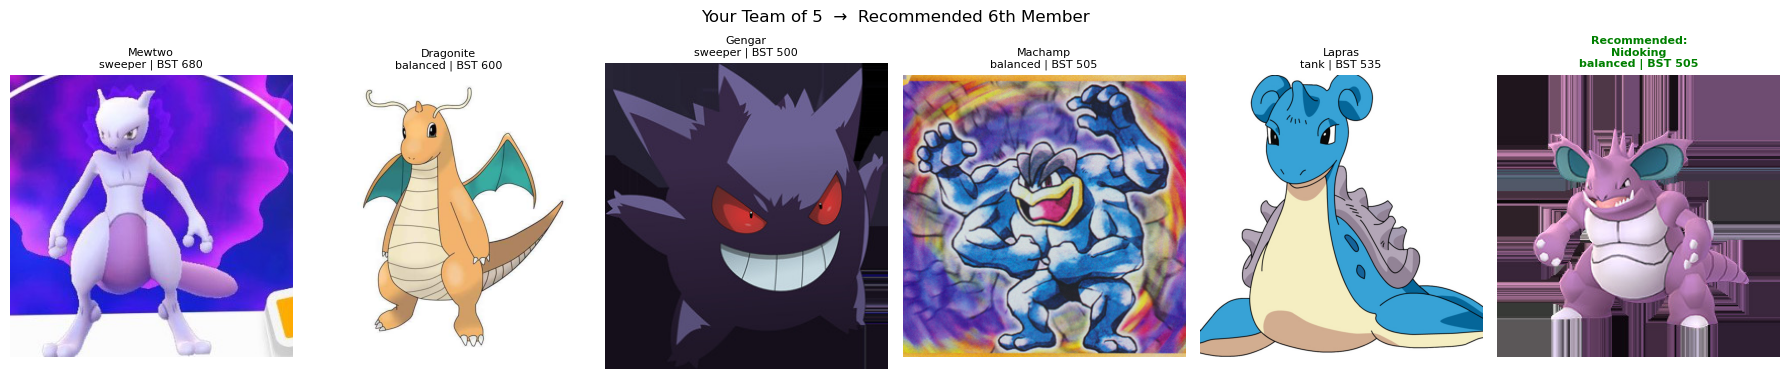


------------------------------------------------------------
Team 3
Team          : ['Arcanine', 'Alakazam', 'Golem', 'Gyarados', 'Jolteon']
Types covered : ['Electric', 'Fire', 'Flying', 'Ground', 'Psychic', 'Rock', 'Water']
Shared weaknesses (≥2 members): ['Grass', 'Ground', 'Ice', 'Rock', 'Water']
Team roles    : {'Arcanine': 'sweeper', 'Alakazam': 'sweeper', 'Golem': 'tank', 'Gyarados': 'balanced', 'Jolteon': 'sweeper'}
Missing roles : none
Candidates    : 23 (BST ≥ 500, chain dedup, no legendaries)

Top 3 recommendations (w_type=1.0, w_weak=1.5, w_role=1.0):
  1. Exeggutor               score=9.2 | new types=['Grass'] | immune=[] resists=['Grass', 'Ground', 'Water'] avoids=['Rock'] | role=balanced | BST=530
  2. Machamp                 score=9.2 | new types=['Fighting'] | immune=[] resists=['Rock'] avoids=['Grass', 'Ground', 'Ice', 'Water'] | role=balanced | BST=505
  3. Poliwrath               score=9.2 | new types=['Fighting'] | immune=[] resists=['Ice', 'Rock', 'Water'] avoids

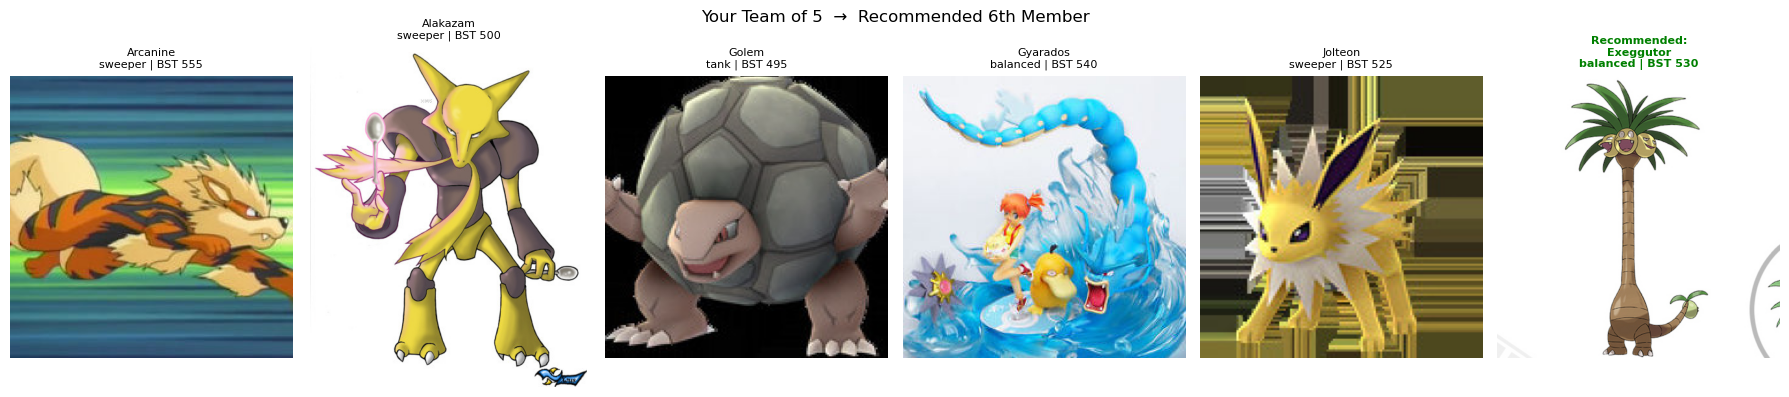

In [17]:
# ── Edit TEAMS ────────────────────────────────────────────────────────────────
TEAMS = [
    ['Charizard', 'Blastoise', 'Venusaur', 'Pikachu', 'Snorlax'],
    ['Mewtwo', 'Dragonite', 'Gengar', 'Machamp', 'Lapras'],
    ['Arcanine', 'Alakazam', 'Golem', 'Gyarados', 'Jolteon'],
]
# ─────────────────────────────────────────────────────────────────────────────

for i, team in enumerate(TEAMS, 1):
    print(f'{"-"*60}')
    print(f'Team {i}')
    top_picks = recommend_sixth(team, top_n=3)
    visualize_team(team, top_picks[0], [random.choice(list_images(DATA_DIR / p)) for p in team])
    print()

---
## 5. Experiment with Weights
Change `w_type`, `w_weak`, `w_role` to see how the ranking shifts.  
For example: setting `w_weak=0` reverts to the original type-only strategy.

In [18]:
# ── Edit team and weights ─────────────────────────────────────────────────────
# All-sweeper team: missing tank and balanced roles → role criterion activates
TEAM = ['Jolteon', 'Alakazam', 'Gengar', 'Charizard', 'Aerodactyl']

WEIGHT_CONFIGS = [
    {'label': 'Type only (original)',      'w_type': 1.0, 'w_weak': 0.0, 'w_role': 0.0},
    {'label': 'Type + weakness',           'w_type': 1.0, 'w_weak': 1.5, 'w_role': 0.0},
    {'label': 'Balanced composite',        'w_type': 1.0, 'w_weak': 1.5, 'w_role': 1.0},
    {'label': 'Weakness-heavy',            'w_type': 0.5, 'w_weak': 2.0, 'w_role': 0.5},
]
# ─────────────────────────────────────────────────────────────────────────────

for cfg in WEIGHT_CONFIGS:
    print(f'\n{"="*60}')
    print(f"Strategy: {cfg['label']}")
    recommend_sixth(TEAM, top_n=3, w_type=cfg['w_type'], w_weak=cfg['w_weak'], w_role=cfg['w_role'])


Strategy: Type only (original)
Team          : ['Jolteon', 'Alakazam', 'Gengar', 'Charizard', 'Aerodactyl']
Types covered : ['Electric', 'Fire', 'Flying', 'Ghost', 'Poison', 'Psychic', 'Rock']
Shared weaknesses (≥2 members): ['Dark', 'Electric', 'Ghost', 'Ground', 'Ice', 'Rock', 'Water']
Team roles    : {'Jolteon': 'sweeper', 'Alakazam': 'sweeper', 'Gengar': 'sweeper', 'Charizard': 'sweeper', 'Aerodactyl': 'sweeper'}
Missing roles : ['balanced', 'tank']
Candidates    : 22 (BST ≥ 500, chain dedup, no legendaries)

Top 3 recommendations (w_type=1.0, w_weak=0.0, w_role=0.0):
  1. Cloyster                score=2.0 | new types=['Ice', 'Water'] | immune=[] resists=['Ice', 'Water'] avoids=['Dark', 'Ghost', 'Ground'] | role=balanced | BST=525
  2. Lapras                  score=2.0 | new types=['Ice', 'Water'] | immune=[] resists=['Ice', 'Water'] avoids=['Dark', 'Ghost', 'Ground'] | role=tank | BST=535
  3. Poliwrath               score=2.0 | new types=['Fighting', 'Water'] | immune=[] resists